<a href="https://colab.research.google.com/github/justsaymel/Challenge_AluraStore/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [3]:
tienda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [18]:
tienda.columns

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

#1. Análisis de facturación



In [4]:
import matplotlib.pyplot as plt

In [5]:
tiendas_dfs = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

In [6]:
facturaciones = []

for df in tiendas_dfs:
    total = pd.to_numeric(df['Precio'], errors='coerce').sum()
    facturaciones.append(total)

df_ventas = pd.DataFrame({
    'Tienda': nombres_tiendas,
    'Facturacion_Total': facturaciones
})

print(df_ventas)

     Tienda  Facturacion_Total
0  Tienda 1       1.150880e+09
1  Tienda 2       1.116344e+09
2  Tienda 3       1.098020e+09
3  Tienda 4       1.038376e+09


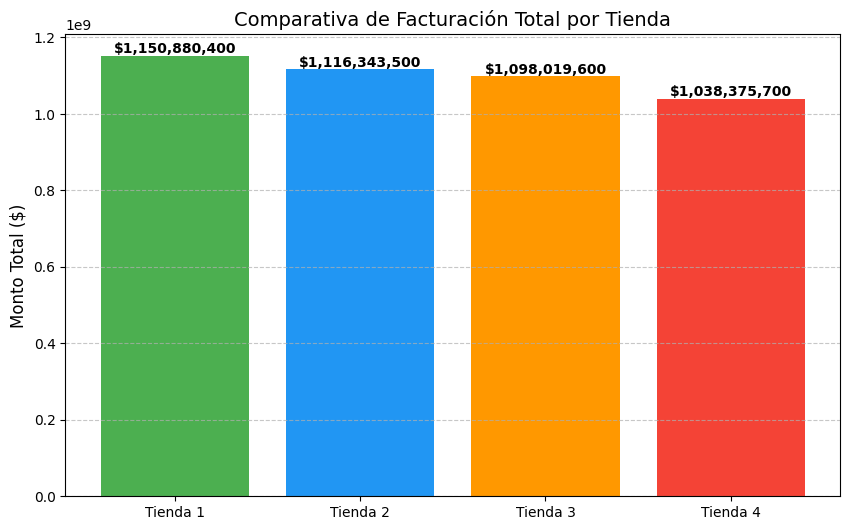

In [7]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df_ventas['Tienda'], df_ventas['Facturacion_Total'], color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval:,.0f}', va='bottom', ha='center', fontweight='bold')

plt.title('Comparativa de Facturación Total por Tienda', fontsize=14)
plt.ylabel('Monto Total ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

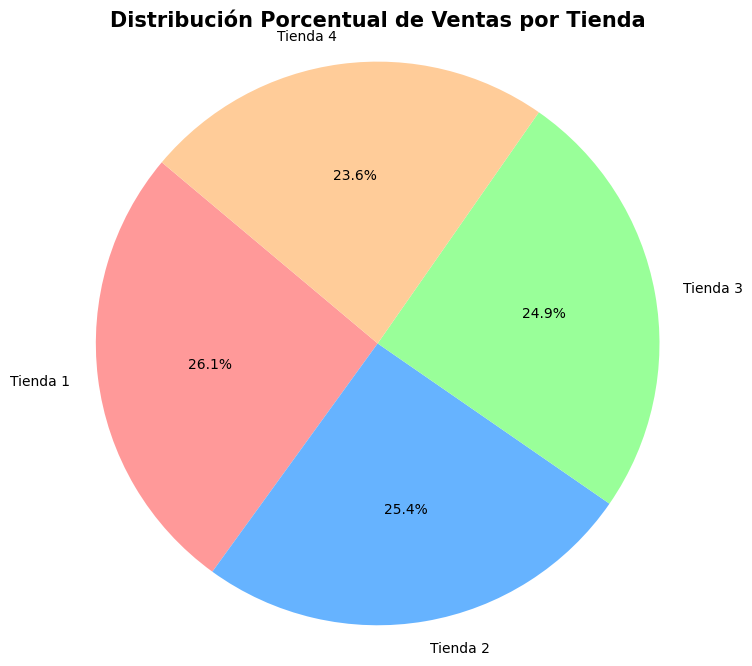

In [8]:
plt.figure(figsize=(8, 8))
colores = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

plt.pie(
    df_ventas['Facturacion_Total'],
    labels=df_ventas['Tienda'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colores
)

plt.title('Distribución Porcentual de Ventas por Tienda', fontsize=15, fontweight='bold')
plt.axis('equal')

plt.show()

# 2. Ventas por categoría

In [81]:
print("CATEGORÍAS POR TIENDA")
for nombre, df in zip(nombres_tiendas, tiendas_dfs):
    print(f"\n{nombre}:")
    print(df['Categoría del Producto'].value_counts().head(3))

CATEGORÍAS POR TIENDA

Tienda 1:
Categoría del Producto
Muebles         465
Electrónicos    448
Juguetes        324
Name: count, dtype: int64

Tienda 2:
Categoría del Producto
Muebles         442
Electrónicos    422
Juguetes        313
Name: count, dtype: int64

Tienda 3:
Categoría del Producto
Muebles         499
Electrónicos    451
Juguetes        315
Name: count, dtype: int64

Tienda 4:
Categoría del Producto
Muebles         480
Electrónicos    451
Juguetes        338
Name: count, dtype: int64


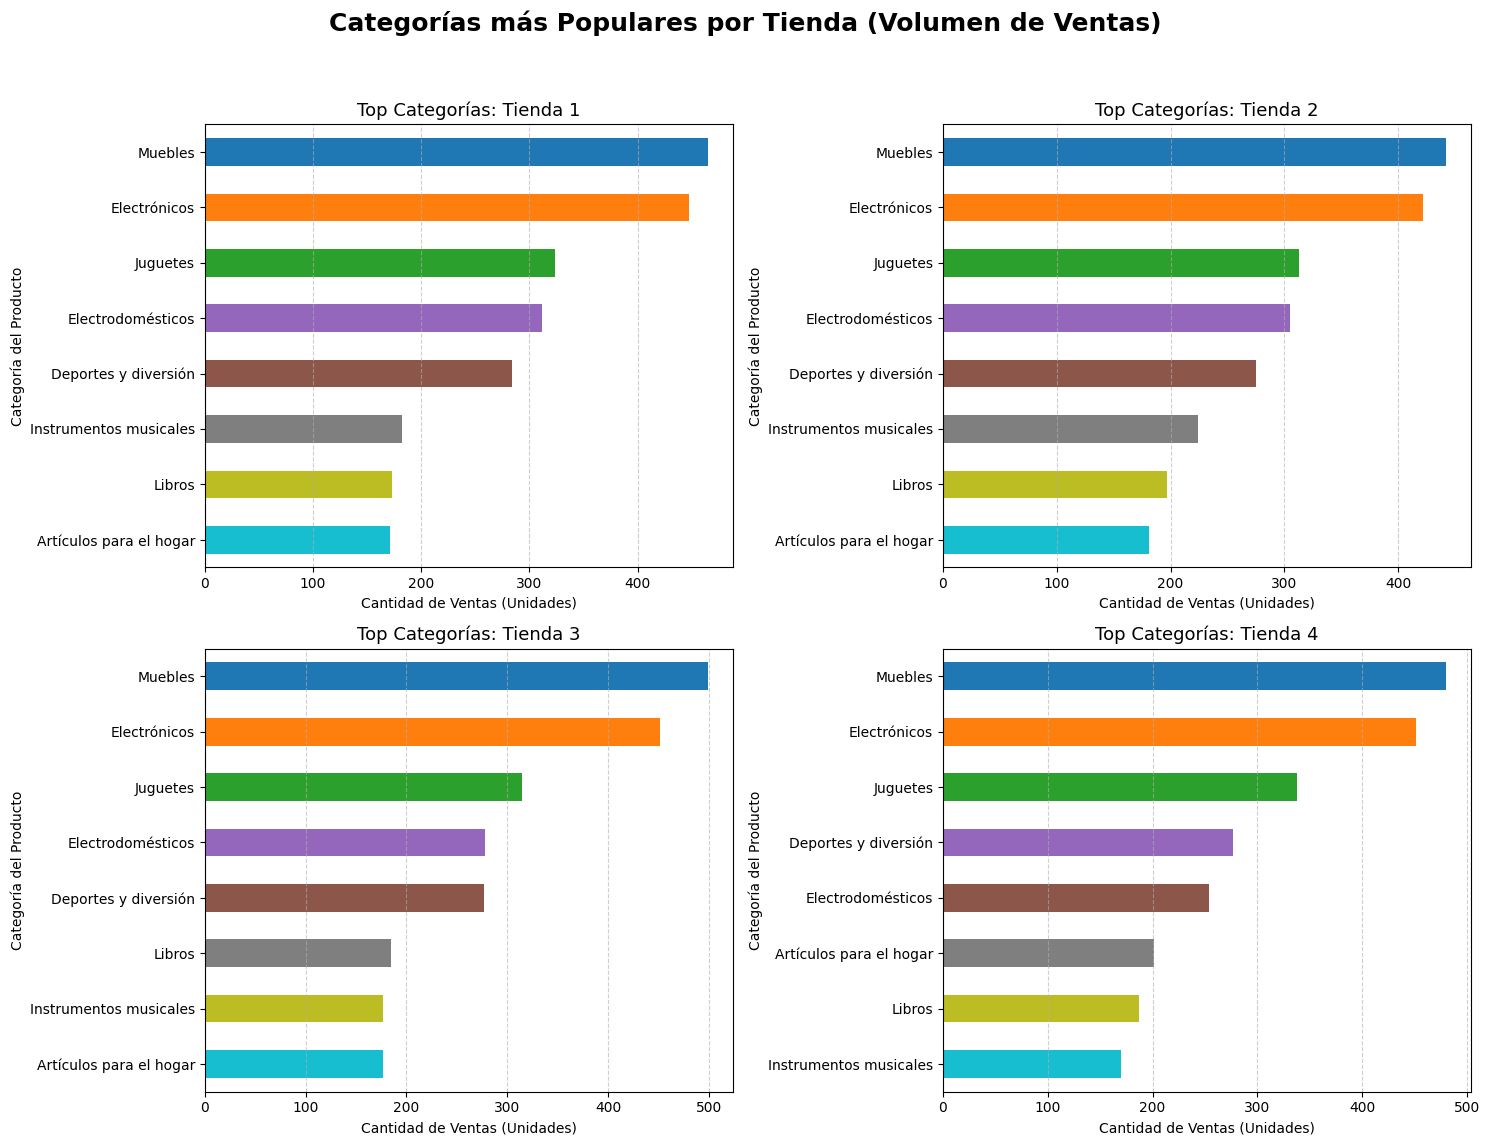

In [10]:
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Categorías más Populares por Tienda (Volumen de Ventas)', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, df in enumerate(tiendas_dfs):
    top_categorias = df['Categoría del Producto'].value_counts()
    colores = cm.tab10(np.linspace(0, 1, len(top_categorias)))
    top_categorias.plot(kind='barh', ax=axes[i], color=colores)
    axes[i].set_title(f'Top Categorías: {nombres_tiendas[i]}', fontsize=13)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Cantidad de Ventas (Unidades)')
    axes[i].grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

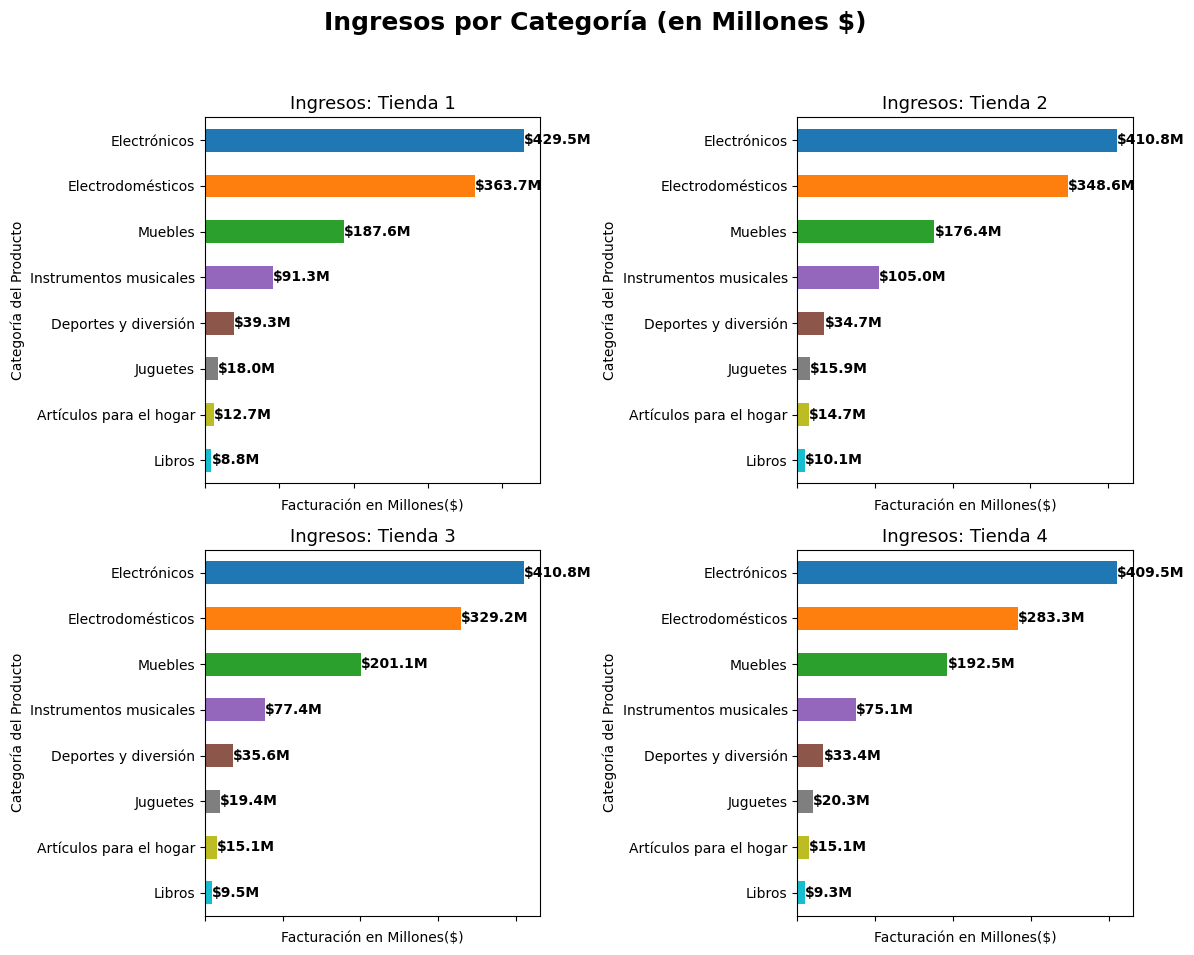

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Ingresos por Categoría (en Millones $)', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, df in enumerate(tiendas_dfs):
    ventas_por_cat = df.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
    colores = cm.tab10(np.linspace(0, 1, len(ventas_por_cat)))
    bars = ventas_por_cat.plot(kind='barh', ax=axes[i], color=colores)
    for bar in axes[i].patches:
        valor = bar.get_width()
        label = f'${valor/1_000_000:.1f}M'
        axes[i].text(valor, bar.get_y() + bar.get_height()/2, label,
                     va='center', ha='left', fontsize=10, fontweight='bold')

    axes[i].set_title(f'Ingresos: {nombres_tiendas[i]}', fontsize=13)
    axes[i].invert_yaxis()
    axes[i].set_xticklabels([])
    axes[i].set_xlabel('Facturación en Millones($)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

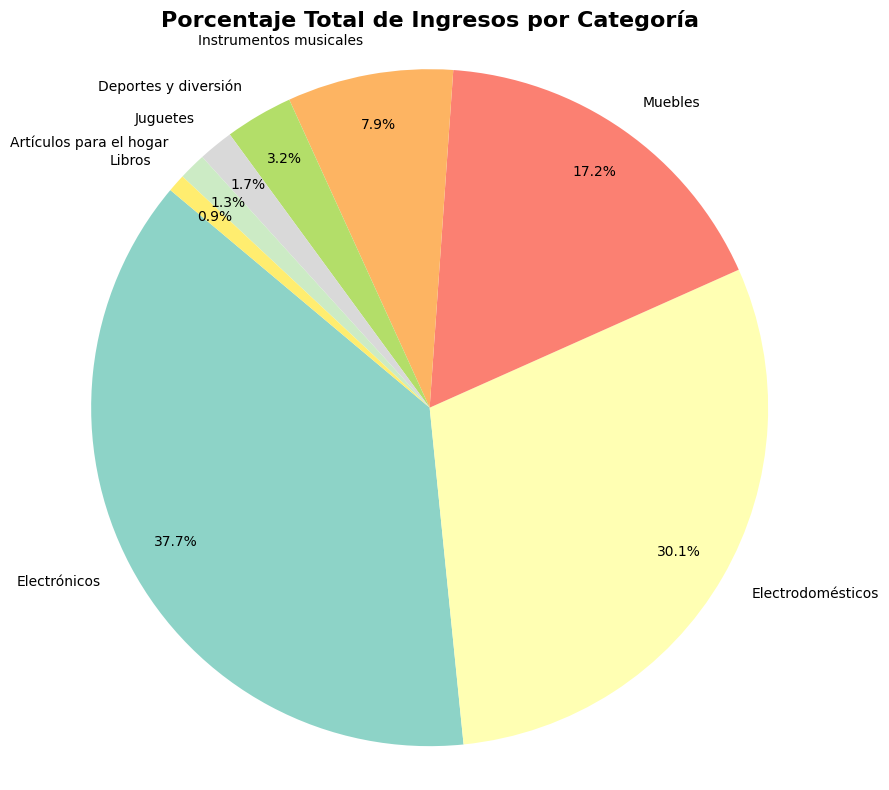

In [16]:
df_global = pd.concat(tiendas_dfs)
ventas_global_cat = df_global.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 8))
colores = cm.Set3(np.linspace(0, 1, len(ventas_global_cat)))
plt.pie(
    ventas_global_cat,
    labels=ventas_global_cat.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colores,
    pctdistance=0.85,
)

plt.title('Porcentaje Total de Ingresos por Categoría', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


# 3. Calificación promedio de la tienda


In [27]:
tienda['Calificación'].value_counts(ascending=True)

,count
Calificación,
2,86
3,218
1,319
4,444
5,1292


In [42]:
df_global['Calificación'] = pd.to_numeric(df_global['Calificación'], errors='coerce')

calificaciones_data = []
for i, df in enumerate(tiendas_dfs):
    calificaciones_data.append({
        'Tienda': nombres_tiendas[i],
        'Promedio_Calificacion': df['Calificación'].mean()
    })

df_ordenado = pd.DataFrame(calificaciones_data)
df_ordenado = df_ordenado.sort_values(by='Promedio_Calificacion', ascending=False)

print("--- Ranking de Calificación ---")
print(df_ordenado.to_string(index=False, formatters={'Promedio_Calificacion': '{:.2f}'.format}))

--- Ranking de Calificación ---
  Tienda Promedio_Calificacion
Tienda 3                  4.05
Tienda 2                  4.04
Tienda 4                  4.00
Tienda 1                  3.98


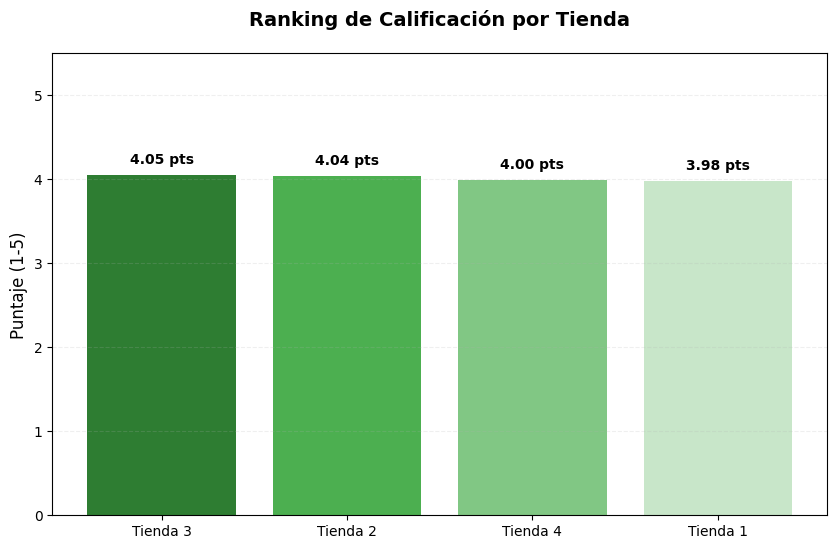

In [43]:
plt.figure(figsize=(10, 6))
colores_verdes = ['#2E7D32', '#4CAF50', '#81C784', '#C8E6C9']
bars = plt.bar(
    df_ordenado['Tienda'],
    df_ordenado['Promedio_Calificacion'],
    color=colores_verdes
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.1,
        f'{yval:.2f} pts',
        va='bottom',
        ha='center',
        fontweight='bold'
    )

plt.title('Ranking de Calificación por Tienda', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Puntaje (1-5)', fontsize=12)
plt.ylim(0, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.show()

# 4. Productos más y menos vendidos

In [58]:
df_global['Producto'].value_counts()

,count
Producto,
Mesa de noche,210
Carrito de control remoto,206
Microondas,206
Batería,203
Cama king,201
Secadora de ropa,200
Modelado predictivo,200
Set de ollas,200
Cama box,199


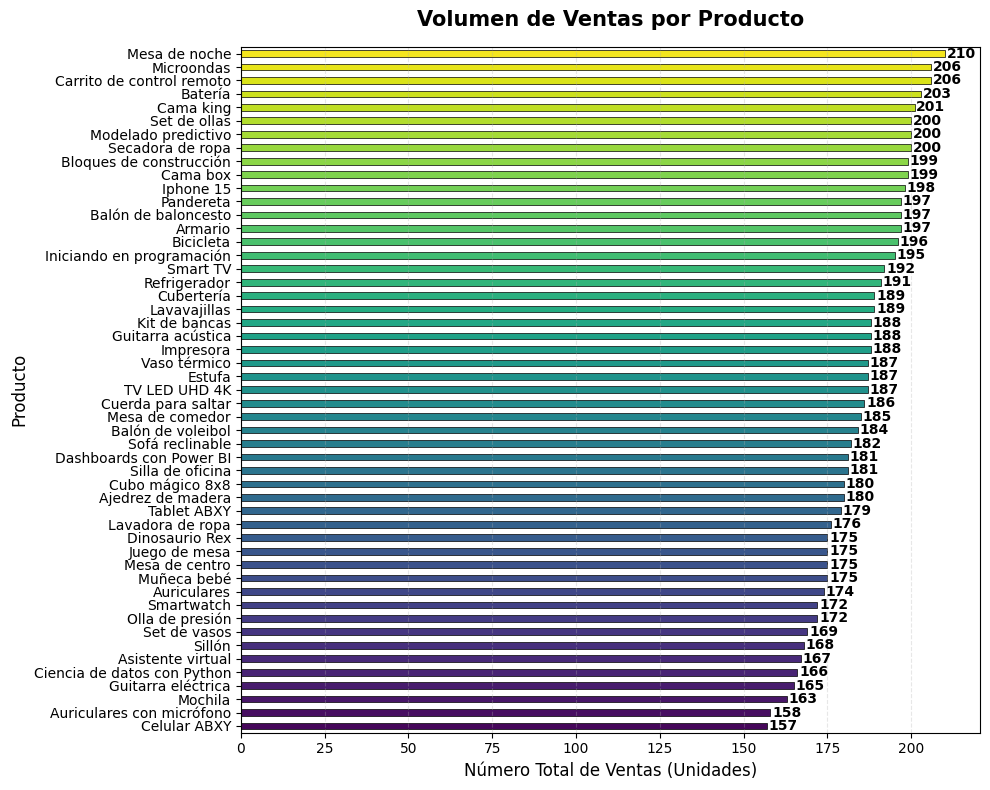

Producto más popular: Mesa de noche (210 ventas)
Producto menos popular: Celular ABXY (157 ventas)


In [54]:
import seaborn as sns

ventas_por_cantidad = df_global['Producto'].value_counts().sort_values(ascending=True)
n_productos = len(ventas_por_cantidad)
paleta_dinamica = sns.color_palette("viridis", n_colors=n_productos)

plt.figure(figsize=(10, 8))
ventas_por_cantidad.plot(kind='barh', color=paleta_dinamica, edgecolor='black', linewidth=0.5)
plt.title('Volumen de Ventas por Producto', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Número Total de Ventas (Unidades)', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

for i, v in enumerate(ventas_por_cantidad):
    plt.text(v + 0.5, i, str(int(v)), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Producto más popular: {ventas_por_cantidad.idxmax()} ({ventas_por_cantidad.max()} ventas)")
print(f"Producto menos popular: {ventas_por_cantidad.idxmin()} ({ventas_por_cantidad.min()} ventas)")

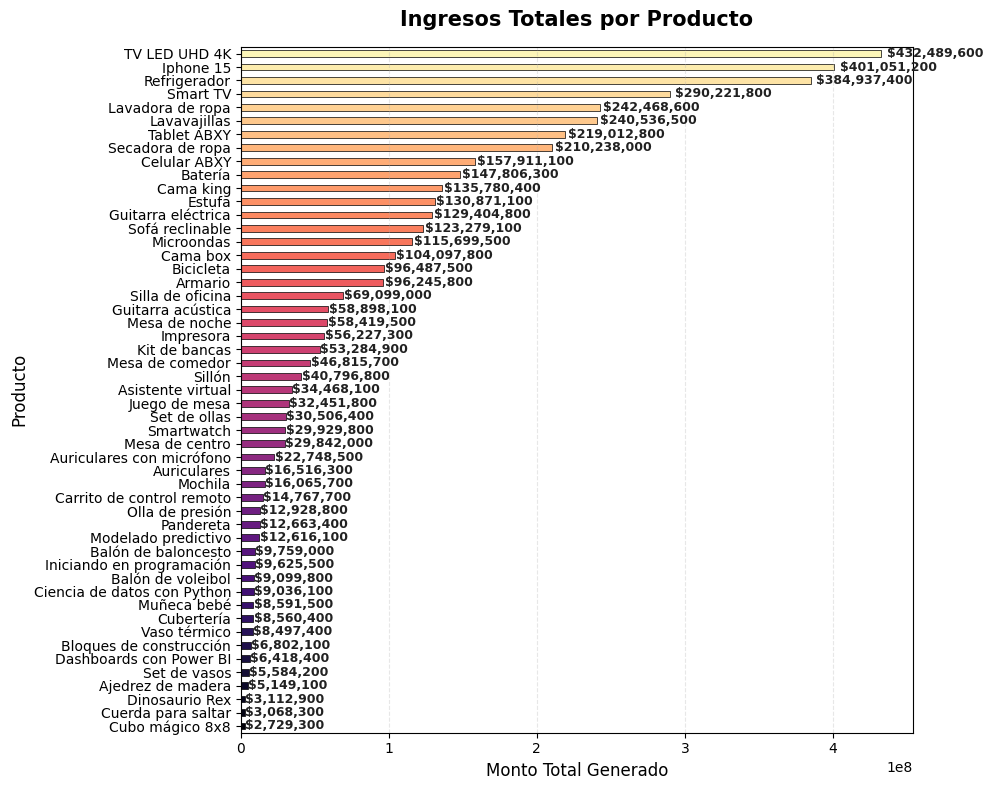

Producto que genera más dinero: TV LED UHD 4K ($432,489,600.00)
Producto que genera menos dinero: Cubo mágico 8x8 ($2,729,300.00)


In [56]:
df_global['Precio'] = pd.to_numeric(df_global['Precio'], errors='coerce')
ventas_por_ingreso = df_global.groupby('Producto')['Precio'].sum().sort_values(ascending=True)
n_productos = len(ventas_por_ingreso)
paleta_rentabilidad = sns.color_palette("magma", n_colors=n_productos)

plt.figure(figsize=(10, 8))
ventas_por_ingreso.plot(
    kind='barh',
    color=paleta_rentabilidad,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Ingresos Totales por Producto', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Monto Total Generado', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

for i, v in enumerate(ventas_por_ingreso):
    plt.text(v + (v * 0.01), i, f'${v:,.0f}', va='center', fontsize=9, fontweight='bold', color='#212121')

plt.tight_layout()
plt.show()
print(f"Producto que genera más dinero: {ventas_por_ingreso.idxmax()} (${ventas_por_ingreso.max():,.2f})")
print(f"Producto que genera menos dinero: {ventas_por_ingreso.idxmin()} (${ventas_por_ingreso.min():,.2f})")

# 5. Envío promedio por tienda

In [59]:
df_global['Costo de envío'].value_counts()

,count
Costo de envío,
$0.00,827
"$1,500.00",81
"$2,600.00",77
"$3,300.00",77
"$2,300.00",76
...,...
"$87,200.00",1
"$132,000.00",1
"$103,300.00",1


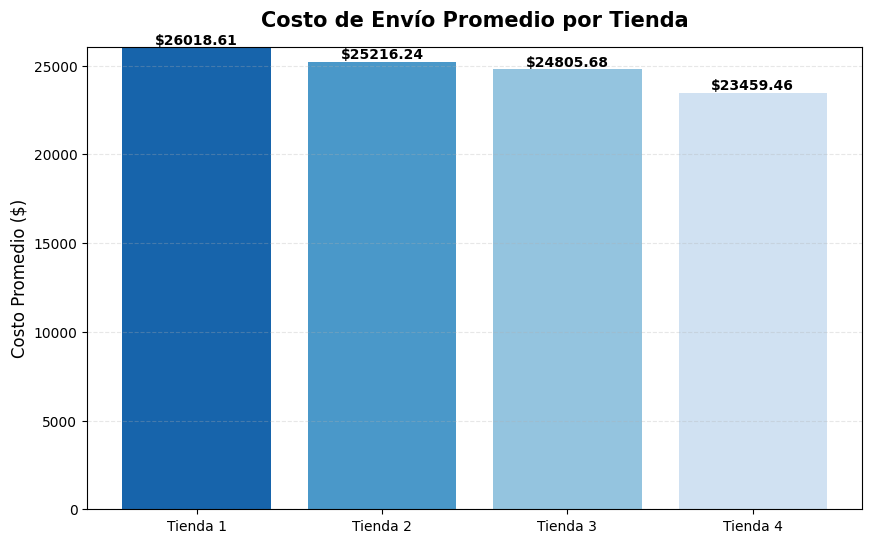

--- Comparativa de Costos de Logística ---
Tienda 1: $26018.61 promedio por envío
Tienda 2: $25216.24 promedio por envío
Tienda 3: $24805.68 promedio por envío
Tienda 4: $23459.46 promedio por envío


In [67]:
df_global['Costo de envío'] = pd.to_numeric(df_global['Costo de envío'], errors='coerce')
costo_envio_tienda = df_global.groupby('Tienda_Origen')['Costo de envío'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
paleta_envio = sns.color_palette("Blues_r", n_colors=len(costo_envio_tienda))

bars = plt.bar(
    costo_envio_tienda.index,
    costo_envio_tienda.values,
    color=paleta_envio,
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f'${yval:.2f}',
        va='bottom',
        ha='center',
        fontweight='bold'
    )

plt.title('Costo de Envío Promedio por Tienda', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Costo Promedio ($)', fontsize=12)
plt.ylim(0, costo_envio_tienda.max() + 10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()
print("--- Comparativa de Costos de Logística ---")
for tienda, valor in costo_envio_tienda.items():
    print(f"{tienda}: ${valor:.2f} promedio por envío")

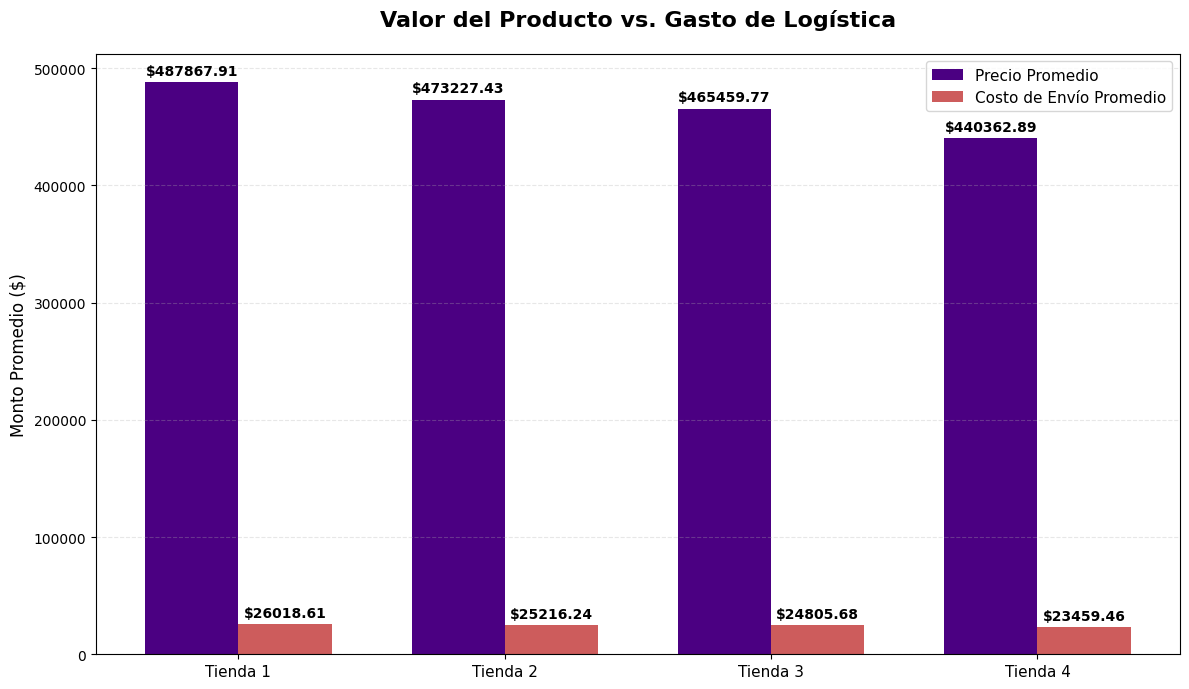

--- Análisis de Impacto de Envío ---
                   Precio  Costo de envío  %_Envio_sobre_Precio
Tienda_Origen                                                  
Tienda 1      $487,867.91      $26,018.61                 $5.33
Tienda 2      $473,227.43      $25,216.24                 $5.33
Tienda 3      $465,459.77      $24,805.68                 $5.33
Tienda 4      $440,362.89      $23,459.46                 $5.33


In [73]:
df_global['Precio'] = pd.to_numeric(df_global['Precio'], errors='coerce')
df_global['Costo de envío'] = pd.to_numeric(df_global['Costo de envío'], errors='coerce')
resumen_costos = df_global.groupby('Tienda_Origen')[['Precio', 'Costo de envío']].mean()
tiendas = resumen_costos.index
x = np.arange(len(tiendas))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, resumen_costos['Precio'], width, label='Precio Promedio', color='#4B0082')
rects2 = ax.bar(x + width/2, resumen_costos['Costo de envío'], width, label='Costo de Envío Promedio', color='#CD5C5C')

ax.set_title('Valor del Producto vs. Gasto de Logística', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Monto Promedio ($)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(tiendas, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()
print("--- Análisis de Impacto de Envío ---")
resumen_costos['%_Envio_sobre_Precio'] = (resumen_costos['Costo de envío'] / resumen_costos['Precio']) * 100
print(resumen_costos[['Precio', 'Costo de envío', '%_Envio_sobre_Precio']].round(2))

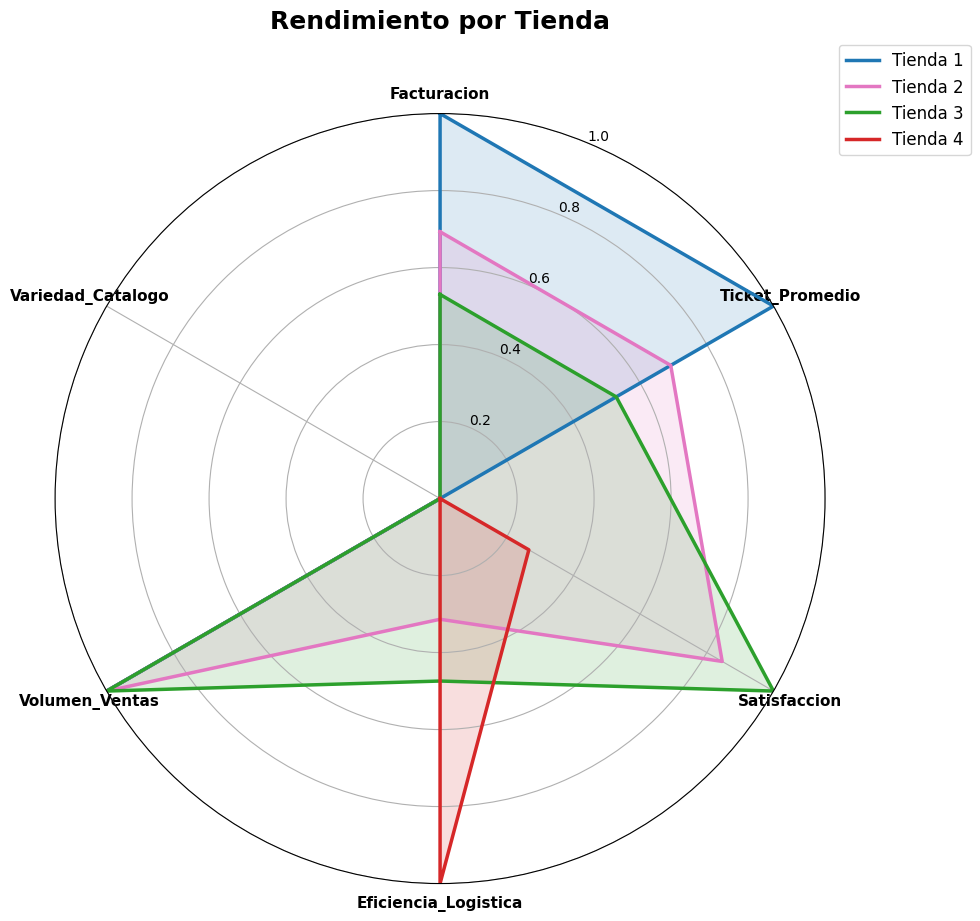

In [78]:
from sklearn.preprocessing import MinMaxScaler

radar_final = df_global.groupby('Tienda_Origen').agg({
    'Precio': ['sum', 'mean'],
    'Calificación': 'mean',
    'Costo de envío': 'mean',
    'Producto': ['count', 'nunique']
})

radar_final.columns = ['Facturacion', 'Ticket_Promedio', 'Satisfaccion', 'Costo_Envio', 'Volumen_Ventas', 'Variedad_Catalogo']
scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(radar_final),
                       columns=radar_final.columns,
                       index=radar_final.index)
df_norm['Costo_Envio'] = 1 - df_norm['Costo_Envio']
df_norm = df_norm.rename(columns={'Costo_Envio': 'Eficiencia_Logistica'})
labels = df_norm.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]


fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = ['#1f77b4', '#e377c2', '#2ca02c', '#d62728']

for i, (tienda, row) in enumerate(df_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2.5, label=tienda)
    ax.fill(angles, values, color=colors[i], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11, fontweight='bold')
ax.set_rlim(0, 1)
ax.set_ylim(0, 1)
plt.title('Rendimiento por Tienda', y=1.1, fontsize=18, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)

plt.show()

# **Informe final**

# 📊 Informe de Análisis Estratégico: Optimización de Sucursales

**Para:** Sr. Juan    

---

## 1. Introducción
El objetivo de este análisis es evaluar el rendimiento integral de las cuatro sucursales del Sr. Juan para identificar cuál de ellas presenta las mayores debilidades operativas y financieras. A través de este estudio multidimensional, se busca fundamentar la decisión de venta de una propiedad, asegurando que el capital restante se enfoque en las unidades de negocio más rentables y prometedoras.

---

## 2. Desarrollo del Análisis

### A. Rendimiento Financiero y Ventas
Tras analizar la facturación total, se observa una brecha clara en la capacidad de generación de ingresos:
* **Líder de Ventas:** La **Tienda 1** encabeza la lista con una facturación de **$1,150.8 millones**.

* **Menor Rendimiento:** La **Tienda 4** registra la cifra más baja con $1,038.3 millones.

Hay una diferencia de más de $112 millones respecto a la sucursal más exitosa, marcando una tendencia de bajo flujo de caja.

### B. Análisis de Productos y Categorías
A pesar de que todas las tiendas comparten un catálogo similar (Muebles, Electrónicos y Juguetes), la **Tienda 4** presenta una contradicción importante:
* Su producto estrella es la **Cama box** y su categoría principal es **Muebles (480 unidades)**.
* **Hallazgo:** Aunque vende artículos de alto valor unitario, no logra superar en ingresos a las otras tiendas. Esto sugiere que el volumen de transacciones es insuficiente o que el mercado local no tiene la fuerza necesaria para sostener una operación de muebles de alta gama.

### C. Satisfacción del Cliente y Logística
* **Voz del Cliente:** El ranking de calificaciones sitúa a la **Tienda 1 (3.98)** y a la **Tienda 4 (4.00)** como las más débiles en servicio. Sin embargo, la Tienda 1 justifica su permanencia con el mayor volumen de ventas, mientras que la Tienda 4 falla en ambos frentes (dinero y satisfacción).
* **Costos de Envío:** La **Tienda 1** es la más ineficiente en logística ($26,018 promedio por envío).

No obstante, la **Tienda 4** tiene el costo más bajo ($23,459), lo que confirma que su bajo ingreso no se debe a precios de envío excesivos, sino a una falta genuina de demanda o volumen.

---

## 3. Diagnóstico Visual: Gráfico de Rendimiento (Radar)
El análisis gráfico mediante el **Heptágono de Rendimiento** revela la salud estructural de cada tienda:
* La **Tienda 4** muestra una geometría de **triángulo isósceles**, lo que significa que su rendimiento está "encogido" hacia el centro del gráfico.
* Su punto más crítico es la **Satisfacción (cerca de 0.2 en escala normalizada)**, indicando que la sucursal está operando en niveles mínimos de aprobación por parte de los clientes.



---

## 4. Conclusión y Recomendación Final

Basado en la evidencia de datos, se recomienda al Sr. Juan proceder con la **venta de la Tienda 4**.

### Justificación de la decisión:
1. **Falta de Competitividad Financiera:** Es la tienda con menor facturación total del grupo, representando el eslabón más débil de la cadena de suministro.
2. **Baja Satisfacción al Cliente:** Con una calificación de 4.00 y un desempeño cerca de 0.2 en el radar de satisfacción, la tienda enfrenta un riesgo reputacional grave que difícilmente se revertirá sin una inversión masiva.
3. **Estrategia de Reinversión:** El capital liberado por la venta de la **Tienda 4** debería utilizarse para optimizar la logística de la **Tienda 1**, la cual, a pesar de tener costos altos, ya ha demostrado ser la sucursal con mayor potencial de ventas.

---